<a href="https://colab.research.google.com/github/Aryan-Gupta2002/Deep-Learning---Tensorflow/blob/main/Image_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Experiment-5**  
Theory Resource :- https://www.notion.so/Image-Segmentation-311634a614f780eaab2aff41010b30bb?source=copy_link



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

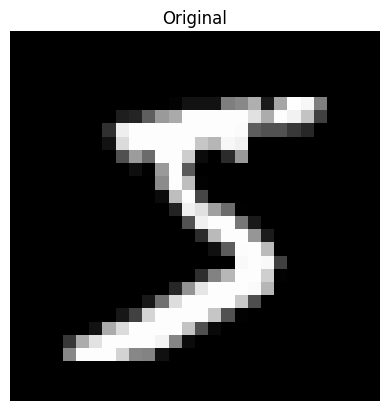

In [ ]:
from tensorflow.keras.datasets import mnist
import cv2
import numpy as np
import matplotlib.pyplot as plt

(x_train, _), _ = mnist.load_data()

img = x_train[0]
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

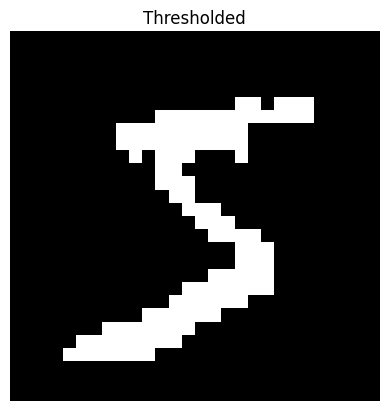

In [ ]:
_, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

plt.imshow(thresh, cmap='gray')
plt.title("Thresholded")
plt.axis("off")

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

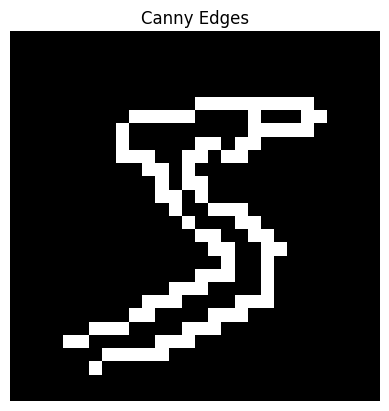

In [ ]:
edges = cv2.Canny(img, 50, 150)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edges")
plt.axis("off")

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

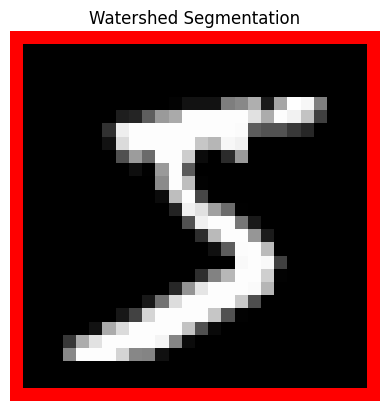

In [ ]:
_, thresh = cv2.threshold(img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
kernel = np.ones((3,3),np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

sure_bg = cv2.dilate(opening,kernel,iterations=3)
dist = cv2.distanceTransform(opening, cv2.DIST_L2,5)
_, sure_fg = cv2.threshold(dist,0.5*dist.max(),255,0)
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg,sure_fg)

_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown==255] = 0

img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
markers = cv2.watershed(img_color, markers)

img_color[markers == -1] = [255,0,0]

plt.imshow(img_color)
plt.title("Watershed Segmentation")
plt.axis("off")